# 05 — Explainable asset selection: one scorecard instead of fifteen arguments

**Tools:** `quantroll.Scorecard` and the `quantroll.measures` library · **Data:** eleven sector ETFs plus TLT (long Treasuries) and GLD (gold), judged against **SPY** as the target, on the last five years of daily returns.

## The big picture

Notebooks 01–04 applied one medicine — *make the arbitrary consistent* — to the **estimation** layer of a quant process: factor axes, regime labels, peer groups, universe maps. But a process does not end at an estimate. It ends at a **decision**: given all these stable analytics, what do we actually hold? And the decision layer suffers its own version of the same disease. When fifteen metrics are combined implicitly in someone's head, the combination is arbitrary, unrepeatable, and unauditable — it shifts from meeting to meeting and person to person, exactly as a solver's sign choice shifts from window to window. Nobody can reconstruct afterwards *why* the fund was picked.

The medicine is also the same: **find the arbitrary step, make it explicit, and hold it fixed.** Alignment did this for estimates; a *scorecard* does it for judgment. This closing notebook is therefore the same story as the previous four, told one layer up.

## The problem, concretely

Every selection meeting has the same shape: someone brings Sharpe ratios, someone counters with maximum drawdown, someone else asks about capture ratios, and the decision ends up made by whoever argued last. The problem is not a shortage of metrics — it is that **fifteen metrics come with no rule for combining them**.

The scorecard's recipe has four steps, which are also the plan of this notebook:

1. **Pick the measures** (§1) — the battery of statistics every asset will be judged on, computed consistently.
2. **Normalize against a target** (§2) — convert raw values into comparable scores, aggregate into a *composite*, and read the *dispersion* diagnostic.
3. **Pick the weights** (§3) — the important step: the weights *are* your investment policy, stated out loud, and changing them visibly re-ranks the universe.
4. **Close the loop** (§4) — check the winner's actual time series against the scorecard's stated reasons.

The output is not a magic number, and the point is not that the top-ranked asset is "the answer." What you gain is that the ranking becomes **reproducible, auditable, and arguable at the right level** — "should drawdown weigh more than volatility?" — instead of the wrong one ("my metric beats your metric").

> *Educational example, not investment advice.*

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantdata as qd
from quantroll import Scorecard, measures

warnings.filterwarnings("ignore", message="All-NaN")
qd.use_style()
PAL = qd.PALETTE

rets = qd.daily_returns(qd.load_prices("etf"))
assets = ["XLK", "XLF", "XLE", "XLV", "XLI", "XLP", "XLY", "XLU", "XLB",
          "XLRE", "XLC", "TLT", "GLD"]
R = rets[assets].loc[rets.index[-1] - pd.DateOffset(years=5):].dropna()
target = rets["SPY"].reindex(R.index)
print(f"judging {len(assets)} assets vs SPY over {R.index[0].date()} -> "
      f"{R.index[-1].date()} ({len(R):,} days)")

judging 13 assets vs SPY over 2021-07-22 -> 2026-07-22 (1,255 days)


## 1. The raw material: thirteen measures, every asset, one call

`Scorecard` computes a default battery of 13 performance measures. Everything downstream is built from these, so here is what each one means, in one line each.

**Absolute measures** — each asset judged on its own return series:

- **CAGR** (compound annual growth rate) — the steady annual return that would have produced the same overall result; "what did it actually make per year."
- **Annualized volatility** — the standard deviation of daily returns scaled to a yearly figure; the standard unit of risk.
- **Sharpe ratio** — return per unit of volatility; the classic risk-adjusted yardstick.
- **Sortino ratio** — like Sharpe, but divides by the volatility of *down* days only, so an asset is not penalized for upside jumpiness.
- **Maximum drawdown** — the worst peak-to-trough decline over the period; how far under water you could have been, had you bought at the worst moment.
- **Calmar ratio** — CAGR divided by maximum drawdown; return per unit of worst-case pain.
- **CVaR 95%** (conditional value-at-risk) — the *average* loss over the worst 5% of days; how bad a bad day typically is, reported as a positive loss magnitude.
- **Skewness** — the asymmetry of the return distribution; negative skew means the big surprises tend to be losses.
- **Hit rate** — the fraction of days the asset was up.

**Target-relative measures** — each asset judged against SPY:

- **Tracking error** — the volatility of the *difference* between the asset's returns and the target's; how far it strays from the benchmark.
- **Information ratio** — average outperformance divided by tracking error; is the straying rewarded?
- **Up capture / down capture** — on the target's up days, what fraction of the target's gain does the asset participate in; and on down days, what fraction of the loss. The ideal profile is high up-capture with low down-capture.

`to_frame()` returns the raw values with the target's own numbers in the first column — so every input to the eventual ranking is inspectable *before* any aggregation happens.

In [2]:
card = Scorecard()
res = card.compare(R, target)
raw = res.to_frame()
raw.round(3)

,target,XLK,XLF,XLE,XLV,XLI,XLP,XLY,XLU,XLB,XLRE,XLC,TLT,GLD
cagr,0.130,0.199,0.108,0.237,0.061,0.133,0.064,0.056,0.106,0.067,0.029,0.072,-0.078,0.176
ann_vol,0.171,0.256,0.184,0.258,0.150,0.175,0.135,0.239,0.173,0.190,0.191,0.208,0.157,0.184
sharpe,0.800,0.836,0.651,0.955,0.467,0.800,0.527,0.349,0.666,0.437,0.244,0.440,-0.435,0.975
sortino,1.161,1.214,0.933,1.350,0.670,1.175,0.745,0.494,0.940,0.634,0.344,0.625,-0.603,1.378
max_drawdown,-0.245,-0.336,-0.258,-0.260,-0.171,-0.216,-0.163,-0.397,-0.253,-0.247,-0.341,-0.467,-0.437,-0.264
calmar,0.532,0.592,0.420,0.910,0.354,0.615,0.393,0.142,0.418,0.272,0.084,0.155,-0.178,0.668
cvar_95,0.025,0.035,0.027,0.037,0.021,0.024,0.019,0.034,0.025,0.026,0.028,0.031,0.022,0.027
skewness,0.314,0.199,-0.069,-0.455,-0.130,0.158,-0.403,0.045,-0.262,0.181,0.022,0.013,0.030,-0.710
hit_rate,0.542,0.559,0.522,0.551,0.510,0.531,0.519,0.530,0.531,0.514,0.519,0.533,0.492,0.539
tracking_error,0.000,0.120,0.114,0.246,0.141,0.094,0.160,0.121,0.182,0.122,0.156,0.115,0.223,0.233


### How to read this

This is the table every meeting already argues over — computed once, consistently, for all thirteen assets: same window, same conventions everywhere (VaR/CVaR reported as positive loss magnitudes at the 95% level, drawdowns negative, ratios annualized from daily data).

Scan any row against the `target` column and the central difficulty of selection appears immediately: an asset can beat SPY on CAGR while losing to it on drawdown and down-capture. Which matters more? The raw table cannot say — it has no notion of importance. That is exactly the ambiguity the next step resolves *explicitly*, rather than leaving it to whoever argues last.

## 2. From values to scores: orientation-adjusted, target-relative

The raw measures live in different units and point in different directions — for volatility, *lower* is better; for CAGR, *higher* is. To make them comparable, each measure is converted to a *score*: the asset's difference from the target, scaled by the size of the target's own value, with the sign flipped for lower-is-better measures. The result is a common currency: **positive always means "better than the target on this measure," and the magnitude means "by this fraction of the target's own level."** The heatmap below shows all of it at once.

ranking (equal weights):
      composite  dispersion
XLK      -0.006       0.589
XLI      -0.054       0.223
XLE      -0.148       0.949
XLF      -0.257       0.343
GLD      -0.261       1.030
XLU      -0.313       0.581
XLB      -0.341       0.331
XLV      -0.360       0.548
XLP      -0.387       0.739
XLC      -0.475       0.344
XLY      -0.514       0.330
XLRE     -0.548       0.456
TLT      -0.875       0.852


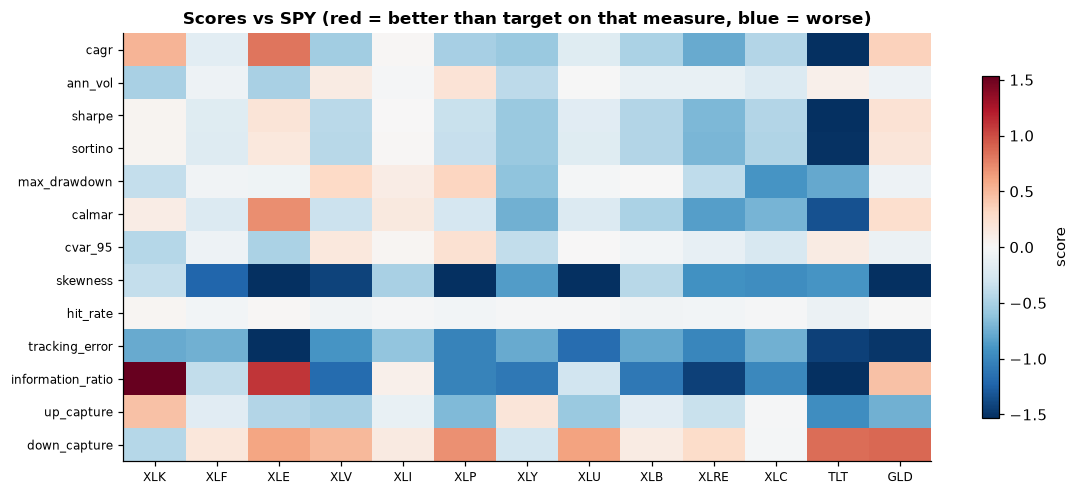

In [3]:
sf = res.scores_frame()
S = sf.drop(index=["composite", "dispersion"])

fig, ax = plt.subplots(figsize=(10.5, 4.6))
vmax = np.nanquantile(np.abs(S.to_numpy()), 0.95)
im = ax.imshow(S.to_numpy(), aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(S.shape[1]), S.columns, rotation=0, fontsize=8)
ax.set_yticks(range(S.shape[0]), S.index, fontsize=8)
ax.set_title("Scores vs SPY (red = better than target on that measure, blue = worse)")
fig.colorbar(im, ax=ax, shrink=0.8, label="score")
ax.grid(False)
plt.tight_layout()

summary = sf.loc[["composite", "dispersion"]].T.sort_values("composite",
                                                            ascending=False)
print("ranking (equal weights):")
print(summary.round(3).to_string())

### How to read this

Each cell of the heatmap answers one question: *is this asset better or worse than SPY on this one measure, and by how much?* Because of the orientation adjustment, **red is always "better than the target," blue always "worse"** — lower volatility scores positive, just as higher CAGR does. Read down a column and you have an asset's complete case at one glance. The heatmap *is* the explanation of the eventual ranking; there is nothing hidden behind it.

Below the measure rows sit the two aggregates:

- **composite** — the weighted average of the column's scores. Positive means the asset beats the target *on balance*, under the stated weights.
- **dispersion** — the weighted *spread* of the scores around that average. This deserves a moment of thought. Two assets can share the same composite while being entirely different propositions: one modestly better than the target on nearly everything (low dispersion — a genuine all-round improvement), the other spectacular on two measures and poor on five (high dispersion — implicitly, a bet that the two good measures are the ones that matter). Given equal composites, the low-dispersion asset is usually what an allocator actually wants.

Two honest observations about the printed table for this particular window:

First, **every composite is negative** — not one sector or diversifier beats a broad, diversified index *on balance*. This should not disappoint you; it is exactly what one should expect when the target *contains* all of the candidates (and it is evidence the scorecard is not flattering anyone). The ranking is still meaningful — it orders the *least bad* trade-offs.

Second, the dispersion row effectively sorts the universe by *how different an asset's overall profile is* from the target. Market-like sectors (industrials, financials, materials) show the lowest dispersion — mildly worse at everything, no surprises. The true diversifiers (gold, energy, long Treasuries) show the highest — much better on some measures, much worse on others. High dispersion is not a defect: it is the quantitative signature of *"this asset is a different animal from your benchmark,"* which is often the very reason to hold it.

## 3. Weights are policy: make them explicit and see what changes

The equal-weighted composite is a neutral default, not a recommendation. A drawdown-averse allocator genuinely cares more about tail measures — so we now say so *explicitly*, in a weights dictionary that triples the weight on drawdown and CVaR, and re-rank.

In [4]:
conservative = Scorecard(weights={
    "max_drawdown": 3, "cvar_95": 3, "ann_vol": 2, "sortino": 2,
    "down_capture": 2, "cagr": 1, "sharpe": 1, "calmar": 1, "skewness": 1,
    "hit_rate": 1, "tracking_error": 0.5, "information_ratio": 0.5,
    "up_capture": 0.5,
})
res_c = conservative.compare(R, target)

cmp = pd.DataFrame({
    "equal-weight rank": pd.Series({a: i + 1 for i, a in enumerate(res.rank())}),
    "conservative rank": pd.Series({a: i + 1 for i, a in enumerate(res_c.rank())}),
}).sort_values("equal-weight rank")
cmp["moved"] = cmp["equal-weight rank"] - cmp["conservative rank"]
print(cmp.to_string())
print("\nbiggest re-ranks under the drawdown-averse policy:")
moved = cmp["moved"].abs().sort_values(ascending=False)
for a in moved.index[:3]:
    print(f"  {a}: {cmp.loc[a, 'equal-weight rank']} -> "
          f"{cmp.loc[a, 'conservative rank']}")

      equal-weight rank  conservative rank  moved
XLK                   1                  8     -7
XLI                   2                  1      1
XLE                   3                  5     -2
XLF                   4                  7     -3
GLD                   5                  2      3
XLU                   6                  6      0
XLB                   7                  9     -2
XLV                   8                  4      4
XLP                   9                  3      6
XLC                  10                 11     -1
XLY                  11                 12     -1
XLRE                 12                 10      2
TLT                  13                 13      0

biggest re-ranks under the drawdown-averse policy:
  XLK: 1 -> 8
  XLP: 9 -> 3
  XLV: 8 -> 4


### How to read this

The re-ranking is the whole point of the exercise. Under the drawdown-averse weights, defensive, shallow-drawdown assets climb the table, while high-octane assets whose case rests on CAGR and up-capture slide down. Neither ranking is "correct" — the two columns encode **different objectives**.

What has changed is *where a disagreement about the outcome must land*. The objective is now a config dictionary in version control, not a mood in a meeting room. When someone disputes the result, the dispute goes to the right place — the weights, which are visible and reviewable — rather than to an invisible mental aggregation that differs from person to person and from meeting to meeting.

## 4. Close the loop: check the winner's time series

A scorecard is a summary, and no summary should be acted on unexamined. Before trusting the ranking, look at the shape of the thing it picked. Below, two charts for the top-ranked asset under the conservative policy: its rolling one-year Sharpe ratio against the target's, and both drawdown paths.

XLI: max drawdown -21.6% vs SPY -24.5%;  CVaR95 2.38% vs 2.47%


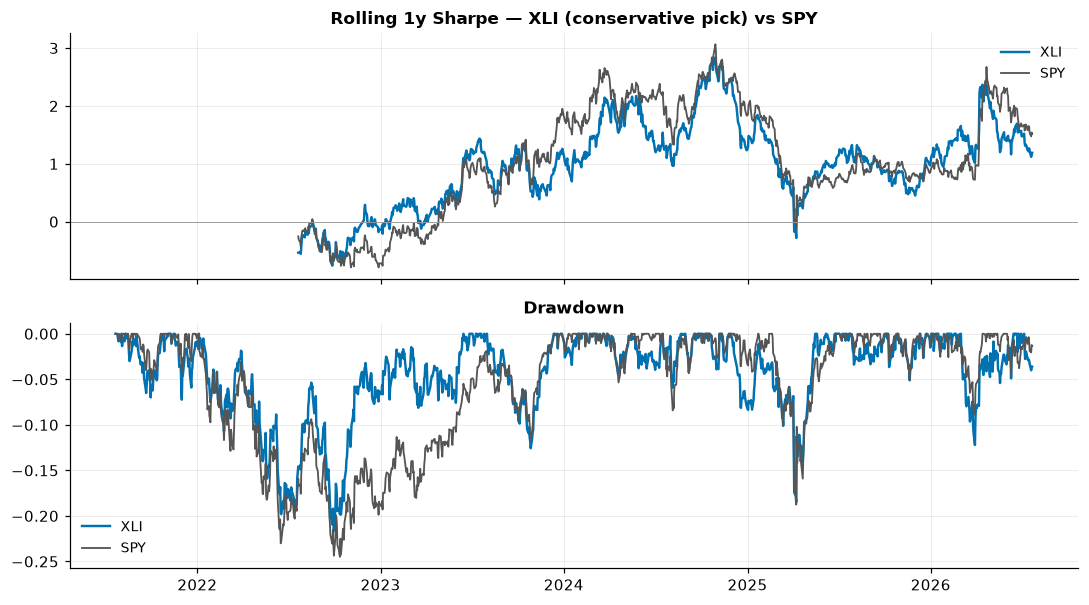

In [5]:
top = res_c.rank()[0]
r_top, r_tgt = R[top].to_numpy(), target.to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
axes[0].plot(R.index, measures.rolling_sharpe(r_top, 252), color=PAL[0],
             label=top)
axes[0].plot(R.index, measures.rolling_sharpe(r_tgt, 252), color=PAL[7],
             label="SPY", lw=1.2)
axes[0].axhline(0, color="#999999", lw=0.6)
axes[0].set_title(f"Rolling 1y Sharpe — {top} (conservative pick) vs SPY")
axes[0].legend()
axes[1].plot(R.index, measures.drawdown_series(r_top), color=PAL[0], label=top)
axes[1].plot(R.index, measures.drawdown_series(r_tgt), color=PAL[7],
             label="SPY", lw=1.2)
axes[1].set_title("Drawdown")
axes[1].legend()
plt.tight_layout()

print(f"{top}: max drawdown {measures.max_drawdown(r_top):+.1%} vs "
      f"SPY {measures.max_drawdown(r_tgt):+.1%};  "
      f"CVaR95 {measures.cvar_hist(r_top):.2%} vs {measures.cvar_hist(r_tgt):.2%}")

### How to read this

The charts should *corroborate the scorecard's reasons* — and here they do. The conservative pick earns its rank in the bottom panel: shallower, shorter drawdowns and thinner tails (the printed numbers quantify both), which is precisely what the drawdown-averse weights asked for. The price of that profile is visible in the top panel: stretches of the rolling-Sharpe race conceded to SPY in strong up-markets. That trade-off is the policy, working as stated.

And if the charts ever *fail* to match the scorecard's story — that is the audit working too. It means one of the measures is being driven by a data artifact or an unrepresentative window, and you found out before the meeting rather than after.

## What you now have — and the series in one view

| Output | Use it for |
|---|---|
| Raw measure table (`to_frame`) | one consistent computation of the metrics everyone already argues with |
| Score heatmap (`scores_frame`) | the *explanation* of every ranking, one glance per asset |
| Composite + dispersion | "beats the target" and "beats it consistently" as separate, honest numbers |
| Weight profiles | selection policy as reviewable config, not meeting-room mood |
| `measures.*` library | ~25 vectorized, NaN-aware primitives for any custom analysis |

### The five notebooks together

| # | Question it answers | Tool |
|---|---|---|
| 01 | What are the market's factors, and is their structure shifting? | `RollingPCA` |
| 02 | What regime are we in, with what probability? | `RollingRegimes` |
| 03 | Which names behave alike, and who is drifting? | `RollingKMeans` |
| 04 | What does the whole universe look like, in one stable picture? | `RollingEmbedding` |
| 05 | Given a target, what should we hold, and *why*? | `Scorecard` |

One idea runs through all five, applied at two layers. At the **estimation** layer (01–04): every rolling tool makes arbitrary choices — signs, orderings, labels, orientations — and making those choices *consistently through time* turns disconnected snapshots into time series whose identity survives from one day to the next. At the **decision** layer (05): the aggregation of evidence into a choice is just as arbitrary when left implicit, and making it *explicit and fixed* turns a meeting-room mood into a reviewable policy. Both are the same discipline — find the arbitrary step, pin it down — and together they are what let analytics be monitored, alerted on, compared, and audited. That is the difference between a chart you make once and a system you run.